In [1]:
!python3 --version
!python3 -m pip install tensorflow pandas numpy scikit-learn matplotlib

Python 3.13.12
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical
from keras.optimizers import Adam

In [ ]:
train = "train_binary.csv"
test = "test_binary.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

In [ ]:
X = df.drop(columns=["label_binary_class"]).values
y = df["label_binary_class"].values

X_test = test_df.drop(columns=["label_binary_class"]).values
y_test = test_df["label_binary_class"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:

def build_cnn(input_shape, num_classes):
    model = Sequential([
        
        Conv1D(64, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        
        Conv1D(256, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Replace Flatten with GAP
        GlobalAveragePooling1D(),

        # Dense head
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(X, y_encoded):
    print(f"\nFold {fold}/10")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)

    model = build_cnn(
        input_shape=(X.shape[1], 1),
        num_classes=num_classes
    )

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=200,
        batch_size=256,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    fold_accuracies.append(val_acc)
    histories.append(history)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1


Fold 1/10
Epoch 1/200


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7473 - loss: 0.6153 - val_accuracy: 0.7195 - val_loss: 0.9242
Epoch 2/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8148 - loss: 0.4396 - val_accuracy: 0.7771 - val_loss: 0.4208
Epoch 3/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8530 - loss: 0.3567 - val_accuracy: 0.8840 - val_loss: 0.2839
Epoch 4/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8673 - loss: 0.3321 - val_accuracy: 0.7437 - val_loss: 0.6734
Epoch 5/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8786 - loss: 0.3061 - val_accuracy: 0.7348 - val_loss: 0.7230
Epoch 6/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8727 - loss: 0.3214 - val_accuracy: 0.6637 - val_loss: 0.8771
Epoch 7/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8819 - loss: 0.3007 - val_accuracy: 0.7876 - val_loss: 0.4243
Epoch 8/200
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8911 - loss: 0.2782 - val_accuracy

In [10]:
print("\nCross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Dev: {np.std(fold_accuracies):.4f}")


Cross-Validation Results
Mean Accuracy: 0.8274
Std Dev: 0.0923


In [12]:
y_cat = to_categorical(y_encoded, num_classes)

final_model = build_cnn(
    input_shape=(X.shape[1], 1),
    num_classes=num_classes
)

final_history = final_model.fit(
    X,
    y_cat,
    epochs=200,
    batch_size=256,
    verbose=1
)

Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7565 - loss: 0.5953
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8389 - loss: 0.3926
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8628 - loss: 0.3391
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8697 - loss: 0.3229
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8800 - loss: 0.3032
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8880 - loss: 0.2840
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8951 - loss: 0.2693
Epoch 8/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8938 - loss: 0.2738
Epoch 9/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8944 - loss: 0.2693
Epoch 10/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8803 - loss: 0.3043
Epoch 11/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8944 - loss: 0.2731
Epoch 12/200
469/469 ━━━━━━━━━

In [13]:
y_test_cat = to_categorical(y_test_encoded, num_classes)

test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nBest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Best Accuracy: 0.9546
Test Loss: 0.1629


581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1200x1200 with 0 Axes>

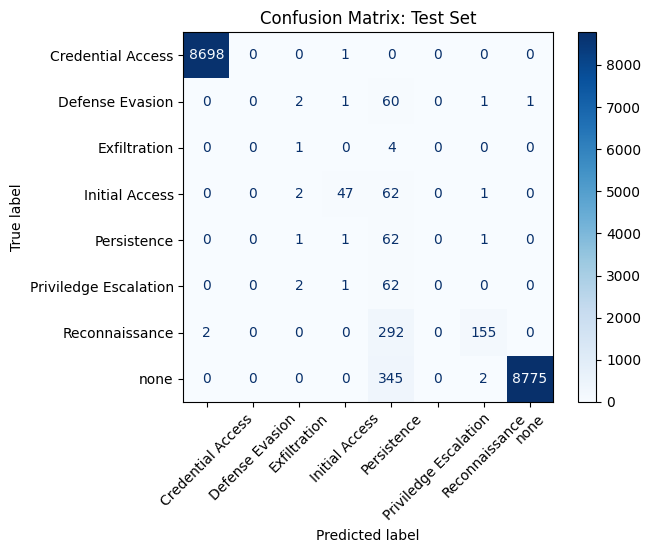

In [14]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix: Test Set")
plt.show()

581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report
                       precision    recall  f1-score   support

    Credential Access       1.00      1.00      1.00      8699
      Defense Evasion       0.00      0.00      0.00        65
         Exfiltration       0.12      0.20      0.15         5
       Initial Access       0.92      0.42      0.58       112
          Persistence       0.07      0.95      0.13        65
Priviledge Escalation       0.00      0.00      0.00        65
       Reconnaissance       0.97      0.35      0.51       449
                 none       1.00      0.96      0.98      9122

             accuracy                           0.95     18582
            macro avg       0.51      0.49      0.42     18582
         weighted avg       0.99      0.95      0.97     18582



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

<Figure size 1200x1200 with 0 Axes>

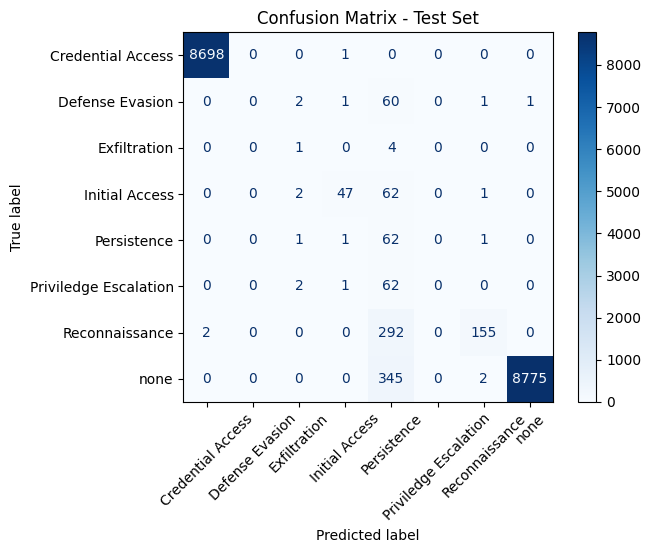


False Positive Rate (per class)
Credential Access: 0.0002
Defense Evasion: 0.0000
Exfiltration: 0.0004
Initial Access: 0.0002
Persistence: 0.0446
Priviledge Escalation: 0.0000
Reconnaissance: 0.0003
none: 0.0001

Average FPR: 0.0057163558937911455


In [15]:

y_test_pred = np.argmax(final_model.predict(X_test), axis=1)


print("\nClassification Report")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))

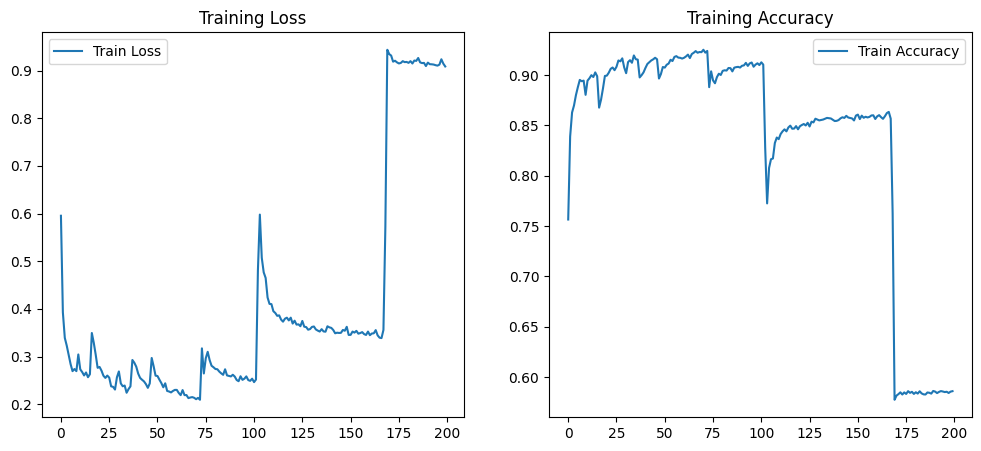

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()